# Analyse des retards par liaison TGV

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.1f}".format)
plt.rcParams["figure.figsize"] = (12, 6)

df = pd.read_csv("../data/processed/regularite_clean.csv", parse_dates=["date"])

SEUIL_TRAINS = 1000
CAUSES = {
    "prct_cause_externe": "Externe",
    "prct_cause_infra": "Infrastructure",
    "prct_cause_gestion_trafic": "Gestion trafic",
    "prct_cause_materiel_roulant": "Matériel roulant",
    "prct_cause_gestion_gare": "Gestion gare",
    "prct_cause_prise_en_charge_voyageurs": "Voyageurs",
}
df.shape

(12471, 30)

## Classement des liaisons

In [2]:
df["minutes_retard"] = df.retard_moyen_arrivee * df.nb_train_retard_arrivee

liaisons = df.groupby("liaison").agg(
    service=("service", "first"),
    nb_circules=("nb_circules", "sum"),
    nb_annulation=("nb_annulation", "sum"),
    nb_retard=("nb_train_retard_arrivee", "sum"),
    nb_retard_sup_60=("nb_train_retard_sup_60", "sum"),
    minutes_retard=("minutes_retard", "sum"),
)
liaisons["taux_retard"] = liaisons.nb_retard / liaisons.nb_circules * 100
liaisons["retard_moyen"] = liaisons.minutes_retard / liaisons.nb_retard
liaisons["taux_sup_60"] = liaisons.nb_retard_sup_60 / liaisons.nb_circules * 100
liaisons["taux_annulation"] = liaisons.nb_annulation / (liaisons.nb_circules + liaisons.nb_annulation) * 100
liaisons = liaisons[liaisons.nb_circules >= SEUIL_TRAINS].drop(columns="minutes_retard")
liaisons = liaisons.sort_values("taux_retard", ascending=False)

taux_moyen = liaisons.nb_retard.sum() / liaisons.nb_circules.sum() * 100
print(len(liaisons), "liaisons retenues")
print(f"Taux de retard moyen : {taux_moyen:.1f} %")

121 liaisons retenues
Taux de retard moyen : 14.5 %


In [3]:
colonnes = ["service", "nb_circules", "nb_retard", "taux_retard", "retard_moyen", "taux_sup_60"]
liaisons[colonnes].head(10)

,service,nb_circules,nb_retard,taux_retard,retard_moyen,taux_sup_60
liaison,,,,,,
ITALIE → PARIS LYON,INTERNATIONAL,6702,2190,32.7,38.7,4.0
CHAMBERY CHALLES LES EAUX → PARIS LYON,NATIONAL,21185,5718,27.0,33.7,2.9
MACON LOCHE → PARIS LYON,NATIONAL,21730,5683,26.2,31.8,2.5
LYON PART DIEU → LILLE,NATIONAL,27861,7255,26.0,36.7,3.7
LYON PART DIEU → MARNE LA VALLEE,NATIONAL,30120,7541,25.0,32.4,2.9
PARIS EST → STUTTGART,INTERNATIONAL,12023,2763,23.0,35.2,2.6
LYON PART DIEU → MARSEILLE ST CHARLES,NATIONAL,43800,9732,22.2,36.6,3.4
DOUAI → PARIS NORD,NATIONAL,16303,3568,21.9,18.4,1.0
ARRAS → PARIS NORD,NATIONAL,40284,8730,21.7,19.6,1.2


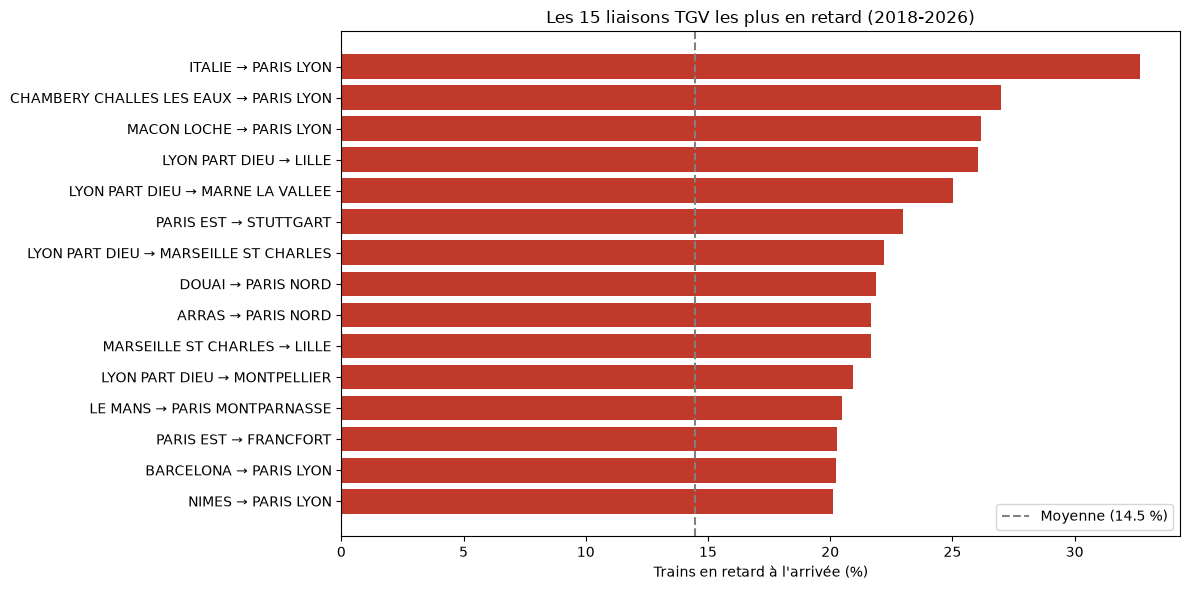

In [4]:
top = liaisons.head(15).sort_values("taux_retard")

fig, ax = plt.subplots()
ax.barh(top.index, top.taux_retard, color="#c0392b")
ax.axvline(taux_moyen, color="grey", linestyle="--", label=f"Moyenne ({taux_moyen:.1f} %)")
ax.set_xlabel("Trains en retard à l'arrivée (%)")
ax.set_title("Les 15 liaisons TGV les plus en retard (2018-2026)")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
liaisons[colonnes].tail(10).sort_values("taux_retard")

,service,nb_circules,nb_retard,taux_retard,retard_moyen,taux_sup_60
liaison,,,,,,
PARIS EST → NANCY,NATIONAL,26684,2203,8.3,35.5,1.2
BESANCON FRANCHE COMTE TGV → PARIS LYON,NATIONAL,16432,1357,8.3,41.8,1.8
PARIS LYON → LYON PART DIEU,NATIONAL,60889,5031,8.3,37.8,1.3
LAUSANNE → PARIS LYON,INTERNATIONAL,13070,1106,8.5,47.7,2.0
ZURICH → PARIS LYON,INTERNATIONAL,13055,1146,8.8,42.6,1.9
PARIS MONTPARNASSE → BREST,NATIONAL,23904,2138,8.9,44.8,1.6
BREST → PARIS MONTPARNASSE,NATIONAL,25095,2270,9.0,43.6,1.6
PARIS LYON → DIJON VILLE,NATIONAL,36702,3324,9.1,37.2,1.5
PARIS MONTPARNASSE → LA ROCHELLE VILLE,NATIONAL,20453,1942,9.5,37.6,1.5


## Retards de plus d'une heure et volumes

In [6]:
liaisons.sort_values("taux_sup_60", ascending=False)[["nb_circules", "nb_retard_sup_60", "taux_sup_60"]].head(10)

,nb_circules,nb_retard_sup_60,taux_sup_60
liaison,,,
BARCELONA → PARIS LYON,5627,279,5.0
MARSEILLE ST CHARLES → TOURCOING,2437,111,4.6
PARIS LYON → ITALIE,6678,284,4.3
NICE VILLE → PARIS LYON,21022,880,4.2
PARIS LYON → BARCELONA,5687,238,4.2
PERPIGNAN → PARIS LYON,18543,748,4.0
ITALIE → PARIS LYON,6702,270,4.0
BORDEAUX ST JEAN → TOURCOING,2499,100,4.0
TOULON → PARIS LYON,26233,1042,4.0


In [7]:
liaisons.sort_values("nb_retard", ascending=False)[["nb_circules", "nb_retard", "taux_retard"]].head(10)

,nb_circules,nb_retard,taux_retard
liaison,,,
BORDEAUX ST JEAN → PARIS MONTPARNASSE,88564,14051,15.9
RENNES → PARIS MONTPARNASSE,69452,11199,16.1
LYON PART DIEU → MARSEILLE ST CHARLES,43800,9732,22.2
PARIS MONTPARNASSE → BORDEAUX ST JEAN,85519,9287,10.9
LILLE → PARIS NORD,57392,9261,16.1
ARRAS → PARIS NORD,40284,8730,21.7
STRASBOURG → PARIS EST,50827,8574,16.9
LE MANS → PARIS MONTPARNASSE,41681,8531,20.5
ST PIERRE DES CORPS → PARIS MONTPARNASSE,44109,8166,18.5


## Causes des retards

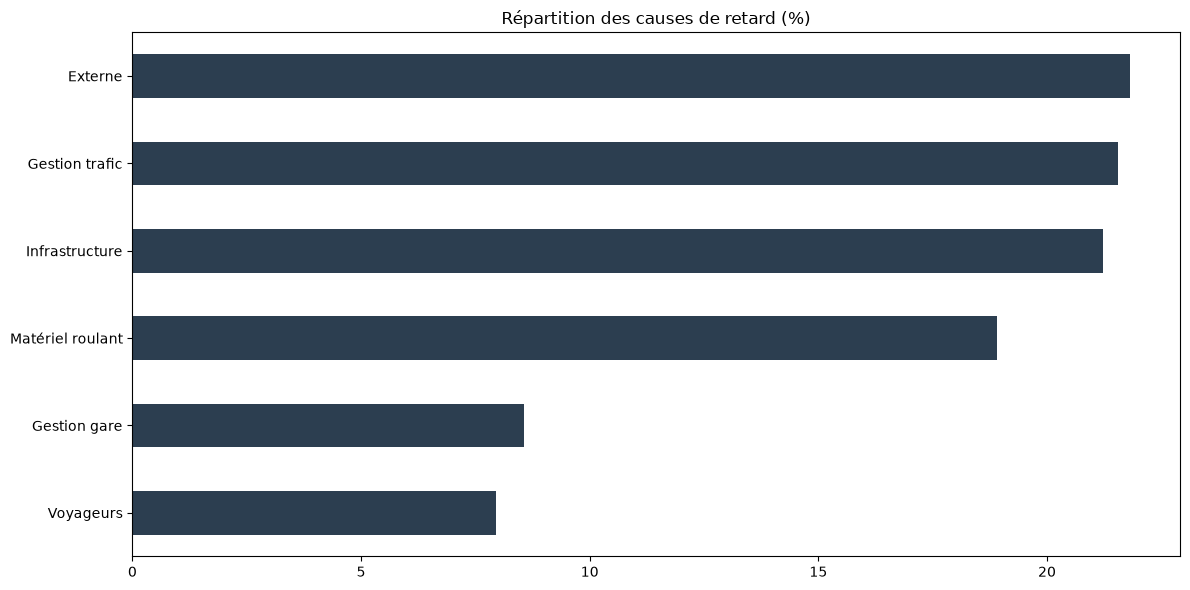

Externe            21.8
Gestion trafic     21.5
Infrastructure     21.2
Matériel roulant   18.9
Gestion gare        8.6
Voyageurs           7.9
dtype: float64

In [8]:
causes_df = df.dropna(subset=list(CAUSES)).copy()
for col in CAUSES:
    causes_df[col] = causes_df[col] * causes_df.nb_train_retard_arrivee / 100

causes_liaison = causes_df.groupby("liaison")[list(CAUSES)].sum().rename(columns=CAUSES)
causes_global = (causes_liaison.sum() / causes_liaison.sum().sum() * 100).sort_values()

causes_global.plot.barh(color="#2c3e50", title="Répartition des causes de retard (%)")
plt.tight_layout()
plt.show()
causes_global.sort_values(ascending=False)

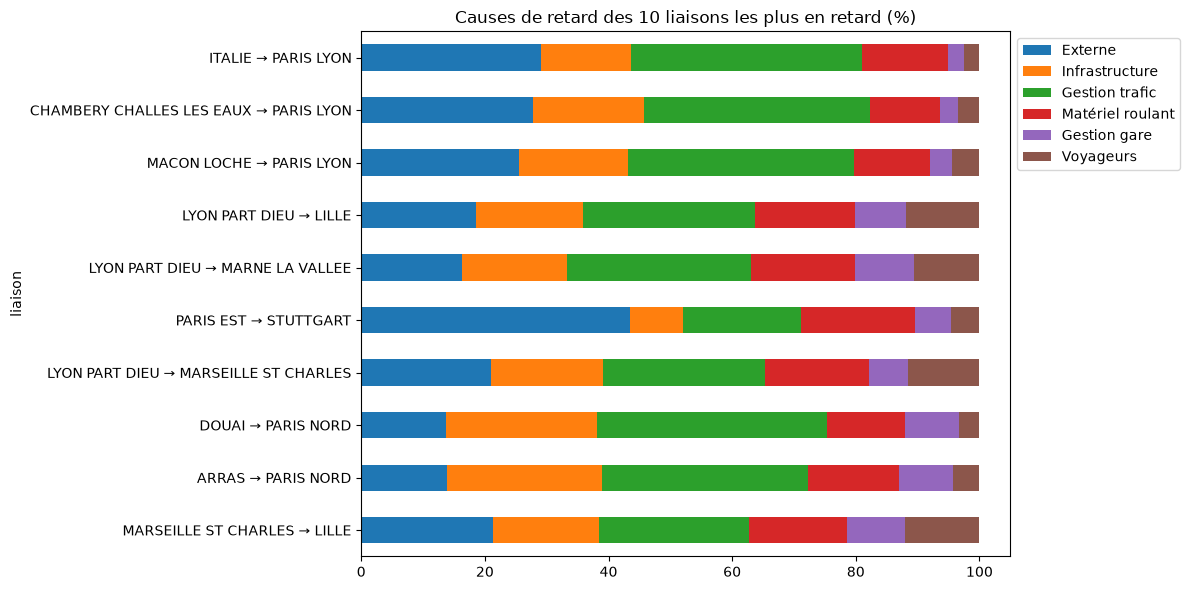

Gestion trafic      34
Matériel roulant    34
Externe             31
Infrastructure      22
Name: count, dtype: int64

In [9]:
causes_pct = causes_liaison.div(causes_liaison.sum(axis=1), axis=0) * 100
causes_top = causes_pct.reindex(liaisons.head(10).index[::-1])

causes_top.plot.barh(stacked=True, title="Causes de retard des 10 liaisons les plus en retard (%)")
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
causes_pct.reindex(liaisons.index).idxmax(axis=1).value_counts()

## Évolution dans le temps

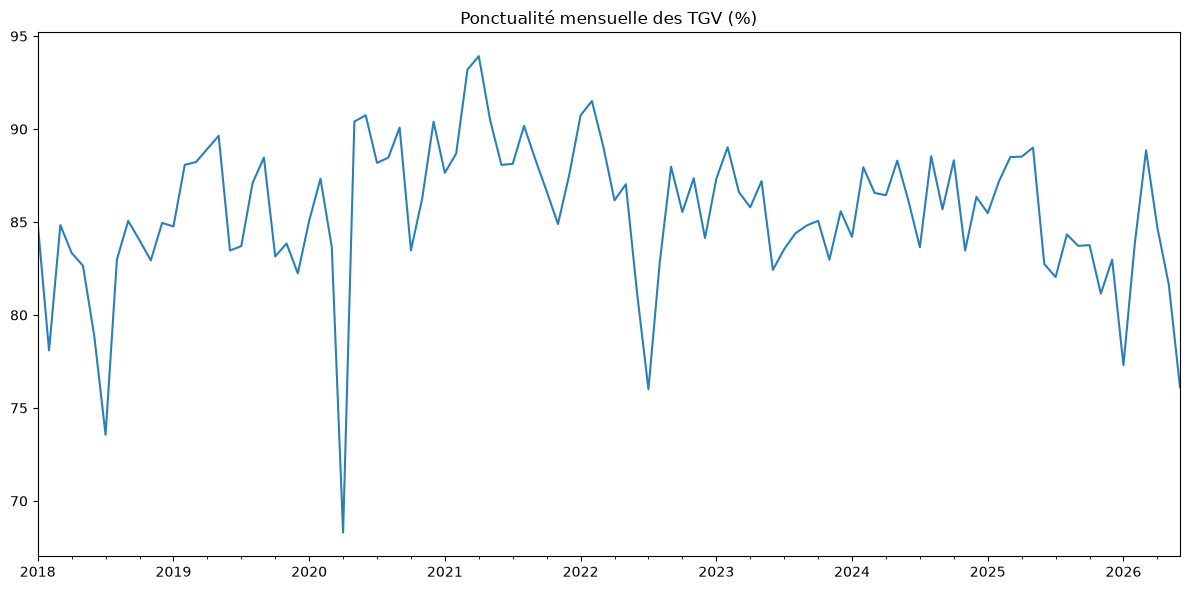

date
2020-04-01   68.3
2018-07-01   73.6
2022-07-01   76.0
2026-06-01   76.1
2026-01-01   77.3
Name: taux_ponctualite, dtype: float64

In [10]:
mensuel = df.groupby("date")[["nb_train_retard_arrivee", "nb_circules"]].sum()
mensuel["taux_ponctualite"] = 100 - mensuel.nb_train_retard_arrivee / mensuel.nb_circules * 100

ax = mensuel.taux_ponctualite.plot(title="Ponctualité mensuelle des TGV (%)", color="#2980b9")
ax.set_xlabel("")
plt.tight_layout()
plt.show()
mensuel.taux_ponctualite.nsmallest(5)

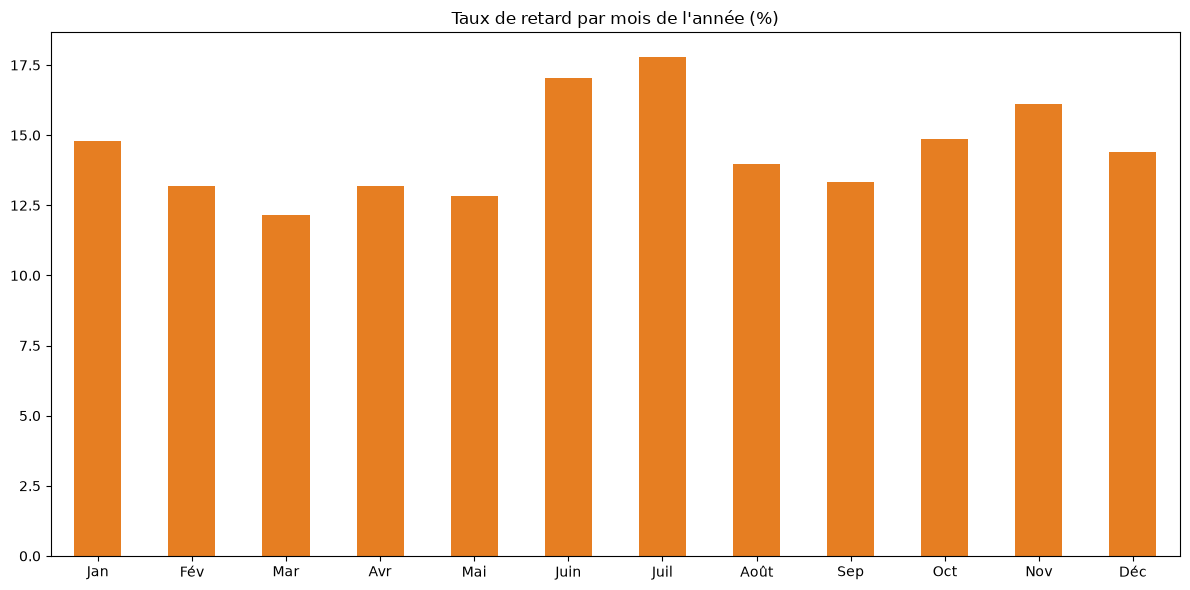

Jan    14.8
Fév    13.2
Mar    12.2
Avr    13.2
Mai    12.8
Juin   17.0
Juil   17.8
Août   14.0
Sep    13.3
Oct    14.9
Nov    16.1
Déc    14.4
Name: taux_retard, dtype: float64

In [11]:
par_mois = df.groupby("mois")[["nb_train_retard_arrivee", "nb_circules"]].sum()
par_mois["taux_retard"] = par_mois.nb_train_retard_arrivee / par_mois.nb_circules * 100
par_mois.index = ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin", "Juil", "Août", "Sep", "Oct", "Nov", "Déc"]

par_mois.taux_retard.plot.bar(color="#e67e22", title="Taux de retard par mois de l'année (%)", rot=0)
plt.tight_layout()
plt.show()
par_mois.taux_retard

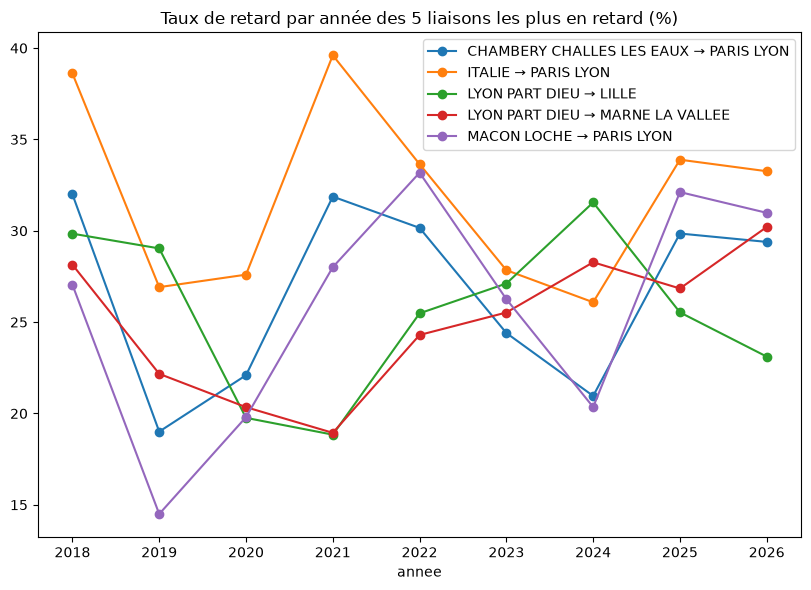

liaison,CHAMBERY CHALLES LES EAUX → PARIS LYON,ITALIE → PARIS LYON,LYON PART DIEU → LILLE,LYON PART DIEU → MARNE LA VALLEE,MACON LOCHE → PARIS LYON
annee,,,,,
2018,32.0,38.6,29.8,28.1,27.0
2019,19.0,26.9,29.0,22.2,14.5
2020,22.1,27.6,19.8,20.3,19.8
2021,31.9,39.6,18.8,18.9,28.0
2022,30.2,33.6,25.5,24.3,33.2
2023,24.4,27.8,27.1,25.5,26.3
2024,21.0,26.1,31.6,28.3,20.3
2025,29.8,33.9,25.5,26.8,32.1
2026,29.4,33.3,23.1,30.2,31.0


In [12]:
pires = liaisons.head(5).index
annuel = df[df.liaison.isin(pires)].groupby(["annee", "liaison"])[["nb_train_retard_arrivee", "nb_circules"]].sum()
annuel = (annuel.nb_train_retard_arrivee / annuel.nb_circules * 100).unstack()

annuel.plot(marker="o", title="Taux de retard par année des 5 liaisons les plus en retard (%)")
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
annuel

## Gares de départ

In [13]:
gares = df.groupby("gare_depart")[["nb_train_retard_arrivee", "nb_circules"]].sum()
gares = gares[gares.nb_circules >= SEUIL_TRAINS * 2]
gares["taux_retard"] = gares.nb_train_retard_arrivee / gares.nb_circules * 100
gares.sort_values("taux_retard", ascending=False).head(10)

,nb_train_retard_arrivee,nb_circules,taux_retard
gare_depart,,,
ITALIE,2190,6702,32.7
CHAMBERY CHALLES LES EAUX,5718,21185,27.0
MACON LOCHE,5683,21730,26.2
DOUAI,3568,16303,21.9
ARRAS,8730,40284,21.7
LE MANS,8531,41681,20.5
BARCELONA,1139,5627,20.2
NIMES,4839,24039,20.1
ANNECY,2759,13795,20.0


In [14]:
export = liaisons.join(causes_pct.add_prefix("cause_"))
export.to_csv("../data/processed/retards_par_liaison.csv")
export.shape

(121, 15)

## Constats
- 121 liaisons analysées (au moins 1 000 trains), taux de retard moyen à l'arrivée : 14,5 %
- Liaison la plus en retard : ITALIE → PARIS LYON (32,7 %), suivie de CHAMBERY et MACON LOCHE → PARIS LYON : l'axe Sud-Est concentre les pires résultats
- Liaisons les plus ponctuelles : PARIS EST → NANCY, BESANCON → PARIS LYON, PARIS LYON → LYON PART DIEU (8,3 %)
- Retards de plus d'une heure : BARCELONA → PARIS LYON en tête (5 % des trains)
- Plus gros volume de trains en retard : BORDEAUX → PARIS MONTPARNASSE (14 051 trains)
- Causes réparties sans cause unique : externe 21,8 %, gestion trafic 21,5 %, infrastructure 21,2 %, matériel roulant 18,9 %
- Juin et juillet sont les mois les plus touchés (17-18 % de retard), mars le moins (12,2 %)
- Pire mois de la période : avril 2020 (68,3 % de ponctualité)